# Лабораторная работа 4

**Тема:** методы поиска условного экстремума.

Вариант 1: `a = 50`, `b = 2`, `f0 = 10`, `n = 2`. Ограничения: `g1 = x1^2 + x2^2 - 1 <= 0`, `g2 = x1^2 - x2 <= 0`, `g3 = x2^2 - x1 <= 0`.

In [1]:
import importlib.util
import subprocess
import sys


def ensure(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

for package, import_name in [('numpy', 'numpy'), ('pandas', 'pandas'), ('matplotlib', 'matplotlib')]:
    ensure(package, import_name)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A = 50.0
B = 2.0
F0 = 10.0

In [2]:
def f(x):
    x = np.asarray(x, dtype=float)
    return F0 + A * (x[1] - x[0] ** 2) ** 2 + B * (1 - x[0]) ** 2


def grad_f(x):
    x = np.asarray(x, dtype=float)
    t = x[1] - x[0] ** 2
    return np.array([-4 * A * x[0] * t - 2 * B * (1 - x[0]), 2 * A * t])


def constraints(x):
    x = np.asarray(x, dtype=float)
    return np.array([
        x[0] ** 2 + x[1] ** 2 - 1,
        x[0] ** 2 - x[1],
        x[1] ** 2 - x[0],
    ])


def jac_constraints(x):
    x = np.asarray(x, dtype=float)
    return np.array([
        [2 * x[0], 2 * x[1]],
        [2 * x[0], -1],
        [-1, 2 * x[1]],
    ])


def feasible(x, tol=1e-7):
    return np.max(constraints(x)) <= tol

print('Безусловная стационарная точка:', np.array([1.0, 1.0]))
print('f(1, 1) =', f([1, 1]))
print('Ограничения в этой точке:', constraints([1, 1]))

Безусловная стационарная точка: [1. 1.]
f(1, 1) = 10.0
Ограничения в этой точке: [1. 0. 0.]


In [3]:
def finite_diff_grad(fun, x, eps=1e-6):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    fx = fun(x)
    for i in range(len(x)):
        h = eps * max(1.0, abs(x[i]))
        xp, xm = x.copy(), x.copy()
        xp[i] += h
        xm[i] -= h
        fp, fm = fun(xp), fun(xm)
        if np.isfinite(fp) and np.isfinite(fm):
            g[i] = (fp - fm) / (2 * h)
        elif np.isfinite(fp) and np.isfinite(fx):
            g[i] = (fp - fx) / h
        elif np.isfinite(fm) and np.isfinite(fx):
            g[i] = (fx - fm) / h
        else:
            g[i] = 0.0
    return g


def bfgs_minimize(fun, x_start, max_iter=300, tol=1e-6, require_strict_feasible=False):
    x = np.asarray(x_start, dtype=float).copy()
    H = np.eye(len(x))
    history = []
    for k in range(max_iter):
        fx = fun(x)
        g = finite_diff_grad(fun, x)
        history.append({'iter': k, 'x1': x[0], 'x2': x[1], 'objective': fx, 'max_g': constraints(x).max()})
        if np.linalg.norm(g) < tol:
            break
        d = -H @ g
        if g @ d >= 0 or not np.all(np.isfinite(d)):
            H = np.eye(len(x))
            d = -g
        alpha = 1.0
        gd = float(g @ d)
        accepted = False
        for _ in range(80):
            candidate = x + alpha * d
            value = fun(candidate)
            ok_feasible = (not require_strict_feasible) or np.all(constraints(candidate) < -1e-10)
            if np.isfinite(value) and ok_feasible and value <= fx + 1e-4 * alpha * gd:
                accepted = True
                break
            alpha *= 0.5
        if not accepted:
            break
        g_next = finite_diff_grad(fun, candidate)
        s = candidate - x
        y = g_next - g
        sy = float(s @ y)
        if sy > 1e-10:
            rho = 1.0 / sy
            I = np.eye(len(x))
            V = I - rho * np.outer(s, y)
            H = V @ H @ V.T + rho * np.outer(s, s)
        else:
            H = np.eye(len(x))
        if np.linalg.norm(s) < tol and abs(value - fx) < tol:
            x = candidate
            break
        x = candidate
    return x, pd.DataFrame(history)

In [4]:
def external_penalty_method():
    x = np.array([-0.7, 0.8])
    r = 1.0
    history = []
    for outer in range(8):
        fun = lambda z, r=r: f(z) + 0.5 * r * np.sum(np.maximum(0, constraints(z)) ** 2)
        x, hist = bfgs_minimize(fun, x, max_iter=200, tol=1e-5)
        hist['outer'] = outer
        hist['method'] = 'Штрафные функции'
        history.append(hist)
        if np.sum(np.maximum(0, constraints(x)) ** 2) < 1e-10:
            break
        r *= 10
    return x, pd.concat(history, ignore_index=True)


def barrier_method():
    x = np.array([0.55, 0.55])
    r = 1.0
    history = []
    for outer in range(7):
        def fun(z, r=r):
            g = constraints(z)
            if np.any(g >= 0):
                return np.inf
            return f(z) - r * np.sum(np.log(-g))
        x, hist = bfgs_minimize(fun, x, max_iter=250, tol=1e-5, require_strict_feasible=True)
        hist['outer'] = outer
        hist['method'] = 'Барьерные функции'
        history.append(hist)
        r /= 5
    return x, pd.concat(history, ignore_index=True)


def combined_penalty_barrier_method():
    x = np.array([0.55, 0.55])
    penalty = 10.0
    barrier = 0.5
    history = []
    for outer in range(7):
        def fun(z, penalty=penalty, barrier=barrier):
            g = constraints(z)
            value = f(z) + 0.5 * penalty * np.sum(np.maximum(0, g) ** 2)
            if np.all(g < 0):
                value -= barrier * np.sum(np.log(-g))
            else:
                value += 1e3 * np.sum(np.maximum(0, g) + 1e-6)
            return value
        x, hist = bfgs_minimize(fun, x, max_iter=250, tol=1e-5)
        hist['outer'] = outer
        hist['method'] = 'Комбинированный метод'
        history.append(hist)
        penalty *= 5
        barrier /= 5
    return x, pd.concat(history, ignore_index=True)


def augmented_lagrangian_method():
    x = np.array([-0.7, 0.8])
    mu = np.zeros(3)
    r = 10.0
    history = []
    for outer in range(10):
        def fun(z, mu=mu.copy(), r=r):
            shifted = np.maximum(0, constraints(z) + mu / r)
            return f(z) + 0.5 * r * np.sum(shifted ** 2) - 0.5 / r * np.sum(mu ** 2)
        x, hist = bfgs_minimize(fun, x, max_iter=250, tol=1e-5)
        hist['outer'] = outer
        hist['method'] = 'Модифицированный Лагранж'
        history.append(hist)
        mu = np.maximum(0, mu + r * constraints(x))
        if np.max(np.maximum(0, constraints(x))) < 1e-7:
            break
        r *= 2
    return x, pd.concat(history, ignore_index=True)

Для проекции градиента после каждого градиентного шага возвращаем точку в допустимую область через короткую вспомогательную минимизацию расстояния до шага.

In [5]:
def project_to_feasible(y, start):
    x = start.copy()
    rho = 1e3
    best = start.copy()
    for _ in range(7):
        fun = lambda z, rho=rho: 0.5 * np.sum((z - y) ** 2) + 0.5 * rho * np.sum(np.maximum(0, constraints(z)) ** 2)
        x, _ = bfgs_minimize(fun, x, max_iter=200, tol=1e-7)
        if constraints(x).max() < constraints(best).max():
            best = x.copy()
        if feasible(x, tol=1e-6):
            return x
        rho *= 10
    return best if feasible(best, tol=1e-6) else start


def projected_gradient_method():
    x = np.array([0.55, 0.55])
    alpha = 0.01
    history = []
    for k in range(300):
        history.append({'iter': k, 'x1': x[0], 'x2': x[1], 'objective': f(x), 'max_g': constraints(x).max(), 'method': 'Проекция градиента'})
        g = grad_f(x)
        accepted = False
        current_alpha = alpha
        for _ in range(25):
            candidate = project_to_feasible(x - current_alpha * g, x)
            if np.linalg.norm(candidate - x) > 1e-10 and feasible(candidate, tol=1e-6) and f(candidate) < f(x):
                accepted = True
                break
            current_alpha *= 0.5
        if not accepted:
            break
        if np.linalg.norm(candidate - x) < 1e-7:
            x = candidate
            break
        x = candidate
        alpha = min(current_alpha * 1.3, 0.05)
    return x, pd.DataFrame(history)

In [6]:
method_functions = {
    'Штрафные функции': external_penalty_method,
    'Барьерные функции': barrier_method,
    'Комбинированный метод': combined_penalty_barrier_method,
    'Модифицированный Лагранж': augmented_lagrangian_method,
    'Проекция градиента': projected_gradient_method,
}

results = []
histories = []
for name, method in method_functions.items():
    started = time.perf_counter()
    x_opt, hist = method()
    elapsed = time.perf_counter() - started
    histories.append(hist)
    results.append({
        'method': name,
        'x': x_opt,
        'f': f(x_opt),
        'max_constraint': constraints(x_opt).max(),
        'iterations': len(hist),
        'time_sec': elapsed,
    })

summary = pd.DataFrame(results)
summary['x'] = summary['x'].apply(lambda x: np.round(x, 8))
summary.round(8)

,method,x,f,max_constraint,iterations,time_sec
0,Штрафные функции,"[0.7861154, 0.61797393]",10.091493,3.500000e-06,62,0.009419
1,Барьерные функции,"[0.78600649, 0.61800555]",10.091588,-1.993500e-04,57,0.009248
2,Комбинированный метод,"[0.78607861, 0.61802119]",10.091525,-1.016100e-04,59,0.011111
3,Модифицированный Лагранж,"[0.78614977, 0.61803245]",10.091464,-9.900000e-07,39,0.006690
4,Проекция градиента,"[0.78615189, 0.61803389]",10.091462,9.000000e-07,15,0.067412


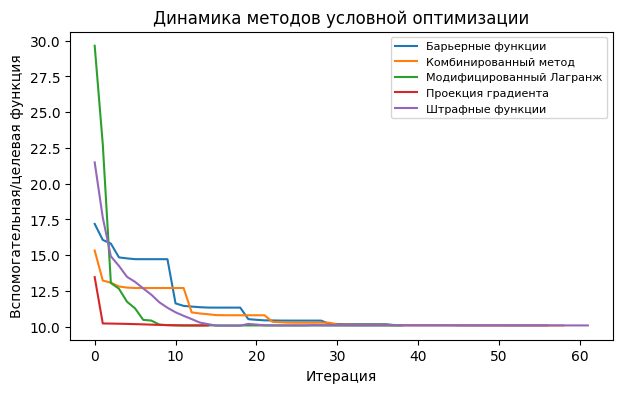

In [7]:
all_history = pd.concat(histories, ignore_index=True)
fig, ax = plt.subplots(figsize=(7, 4))
for name, part in all_history.groupby('method'):
    ax.plot(np.arange(len(part)), part['objective'], label=name)
ax.set_xlabel('Итерация')
ax.set_ylabel('Вспомогательная/целевая функция')
ax.set_title('Динамика методов условной оптимизации')
ax.legend(fontsize=8)
plt.show()

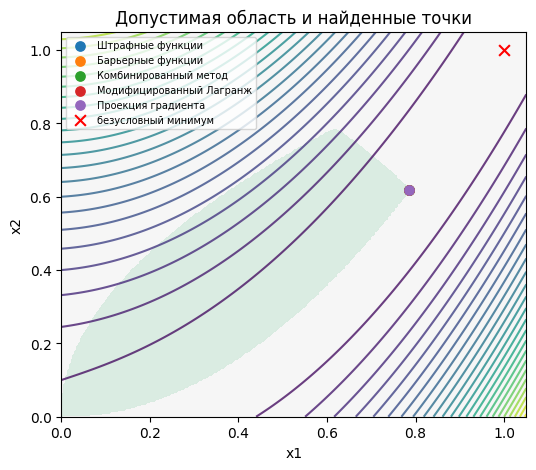

In [8]:
x1 = np.linspace(0.0, 1.05, 260)
x2 = np.linspace(0.0, 1.05, 260)
X1, X2 = np.meshgrid(x1, x2)
G1 = X1 ** 2 + X2 ** 2 - 1
G2 = X1 ** 2 - X2
G3 = X2 ** 2 - X1
F = F0 + A * (X2 - X1 ** 2) ** 2 + B * (1 - X1) ** 2
feasible_mask = (G1 <= 0) & (G2 <= 0) & (G3 <= 0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(X1, X2, feasible_mask, levels=[-0.5, 0.5, 1.5], colors=['#f5f5f5', '#d6eadf'], alpha=0.9)
ax.contour(X1, X2, F, levels=25, cmap='viridis', alpha=0.8)
for row in summary.itertuples():
    point = np.array(row.x, dtype=float)
    ax.scatter(point[0], point[1], s=45, label=row.method)
ax.scatter([1], [1], marker='x', c='red', s=60, label='безусловный минимум')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Допустимая область и найденные точки')
ax.legend(fontsize=7)
plt.show()

In [9]:
# Проверка условий допустимости для найденных решений.
checks = []
for row in summary.itertuples():
    point = np.array(row.x, dtype=float)
    g = constraints(point)
    checks.append({'method': row.method, 'g1': g[0], 'g2': g[1], 'g3': g[2], 'feasible': feasible(point, tol=1e-5)})
pd.DataFrame(checks).round(8)

,method,g1,g2,g3,feasible
0,Штрафные функции,-1.308000e-04,3.490000e-06,-0.404224,True
1,Барьерные функции,-2.629400e-04,-1.993500e-04,-0.404076,True
2,Комбинированный метод,-1.302300e-04,-1.016100e-04,-0.404128,True
3,Модифицированный Лагранж,-4.430000e-06,-9.900000e-07,-0.404186,True
4,Проекция градиента,6.800000e-07,9.000000e-07,-0.404186,True
